In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings

In [3]:
# 1 A)
df = pd.read_csv('/kaggle/input/700-classic-disco-tracks-with-spotify-data/ClassicDisco.csv')

num_rows, num_cols = df.shape
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")

data_types = df.dtypes
print("\ndata types of each column:")
print(data_types)

categorical_vars = df.select_dtypes(include=['object','category']).columns.tolist()
continuous_vars = df.select_dtypes(include=['int64','float64']).columns.tolist()

print("\nCategorical variables:",categorical_vars)
print("Continuous variables:", continuous_vars)

Number of rows: 724
Number of columns: 18

data types of each column:
Track                object
Artist               object
Album                object
Year                  int64
Duration              int64
Time_Signature        int64
Danceability        float64
Energy              float64
Key                   int64
Loudness            float64
Mode                  int64
Speechiness         float64
Acousticness        float64
Instrumentalness    float64
Liveness            float64
Valence             float64
Tempo               float64
Popularity            int64
dtype: object

Categorical variables: ['Track', 'Artist', 'Album']
Continuous variables: ['Year', 'Duration', 'Time_Signature', 'Danceability', 'Energy', 'Key', 'Loudness', 'Mode', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo', 'Popularity']


In [4]:
# 1 B)
numerical_columns = df.select_dtypes(include=['float64','int64']).columns
five_point_summary = df[numerical_columns].describe(percentiles=[0.25,0.5,0.75])
print(five_point_summary.loc[['min','25%','50%','75%','max']])

       Year    Duration  Time_Signature  Danceability   Energy   Key  \
min  1967.0   127053.00             3.0       0.29300  0.03480   0.0   
25%  1976.0   230659.50             4.0       0.61875  0.54975   2.0   
50%  1978.0   280816.50             4.0       0.70800  0.68900   5.0   
75%  1980.0   353456.25             4.0       0.78400  0.80575   9.0   
max  2020.0  1008533.00             5.0       0.98000  0.98500  11.0   

     Loudness  Mode  Speechiness  Acousticness  Instrumentalness  Liveness  \
min -23.92000   0.0       0.0232      0.000017          0.000000   0.01730   
25% -12.12450   0.0       0.0365      0.028400          0.000012   0.07060   
50%  -9.70100   1.0       0.0493      0.111000          0.000747   0.10600   
75%  -7.63575   1.0       0.0696      0.278250          0.032700   0.22425   
max  -3.38400   1.0       0.3860      0.962000          0.941000   0.98400   

     Valence      Tempo  Popularity  
min   0.0855   63.10300         0.0  
25%   0.6710  108.5630

In [10]:
# 1 C)
categorical_columns = df.select_dtypes(include=['object','category']).columns

for col in categorical_columns:
    print(f"summary for categorical variables: {col}")
    
    num_categories =df[col].nunique()
    print(f"Number of categories: {num_categories}")
    
    category_counts = df[col].value_counts(normalize=True)*100
    print("Percenatage of observation in each category:")
    print(category_counts.to_string())


summary for categorical variables: Track
Number of categories: 716
Percenatage of observation in each category:
Track
Boogie Oogie Oogie                                                            0.276243
Hold Tight                                                                    0.276243
Back Stabbers                                                                 0.276243
Love Is The Answer                                                            0.276243
Fire                                                                          0.276243
More Than A Woman                                                             0.276243
You And I                                                                     0.276243
Party Lights                                                                  0.276243
Love Is Gonna Get Ya                                                          0.138122
There It Is - Extended Mix                                                    0.138122
Beat the Str

In [12]:
# 1 D)
missing_values = df.isnull().sum()
print("Missing values in each columns:")
print(missing_values[missing_values>0])
print("\n")

numerical_vars = df.select_dtypes(include=['int64','float64'])

print("Outliers detection (using IQR method):")
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1 -1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    outliers = df[(df[col] < lower_bound)| (df[col] > upper_bound)]
    print(f"column '{col}'- numebr of outliers:{outliers.shape[0]}")
    
    print('\n')
    Track = 'Track'
    
    if Track in df.columns:
        class_distribution = df[Track].value_counts(normalize=True)*100
        print("Class distribution in Track variables:")
        print(class_distribution)
        print("\n")

Missing values in each columns:
Series([], dtype: int64)


Outliers detection (using IQR method):
column 'Year'- numebr of outliers:15


Class distribution in Track variables:
Track
Boogie Oogie Oogie       0.276243
Hold Tight               0.276243
Back Stabbers            0.276243
Love Is The Answer       0.276243
Fire                     0.276243
                           ...   
If You Want My Lovin'    0.138122
Love Come Down           0.138122
Shake Down               0.138122
Shame                    0.138122
Tahiti, Tahiti…          0.138122
Name: proportion, Length: 716, dtype: float64


column 'Duration'- numebr of outliers:18


Class distribution in Track variables:
Track
Boogie Oogie Oogie       0.276243
Hold Tight               0.276243
Back Stabbers            0.276243
Love Is The Answer       0.276243
Fire                     0.276243
                           ...   
If You Want My Lovin'    0.138122
Love Come Down           0.138122
Shake Down               0.138122
Sh

In [11]:
df.head()

,Track,Artist,Album,Year,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity
0,Boogie Oogie Oogie,A Taste Of Honey,A Taste Of Honey,1978,245173,4,0.797,0.548,2,-9.228,0,0.0492,0.0401,0.000010,0.0994,0.868,123.686,53
1,Disco Dancin' - 2004 - Remastered,A Taste Of Honey,A Taste Of Honey,1978,210493,4,0.751,0.570,2,-11.645,1,0.0813,0.3710,0.000020,0.1230,0.770,103.408,11
2,Distant,A Taste Of Honey,A Taste Of Honey,1978,260053,4,0.468,0.512,2,-10.187,1,0.1380,0.7820,0.000020,0.2020,0.714,163.400,13
3,Do It Good,A Taste Of Honey,Another Taste (Expanded Edition),1978,342826,4,0.699,0.740,3,-8.625,0,0.0289,0.0714,0.000002,0.1650,0.889,104.168,17
4,If We Loved,A Taste Of Honey,A Taste Of Honey,1978,266200,4,0.463,0.459,6,-11.600,1,0.0296,0.7640,0.000003,0.1580,0.300,129.267,13


In [15]:
# 2 A)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

numerical_vars = df.select_dtypes(include=['int64','float64'])
imputer = SimpleImputer(strategy='mean')
df[numerical_vars.columns] = imputer.fit_transform(numerical_vars)

categorical_vars = df.select_dtypes(include=['object','category'])
imputer_cat = SimpleImputer(strategy='most_frequent')
df[categorical_vars.columns] = imputer_cat.fit_transform(categorical_vars)

print("Missing values handled.")
numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR
    df[col] = np.clip(df[col],lower_bound,upper_bound)
print("outliers handled using capping.")

Missing values handled.
outliers handled using capping.


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


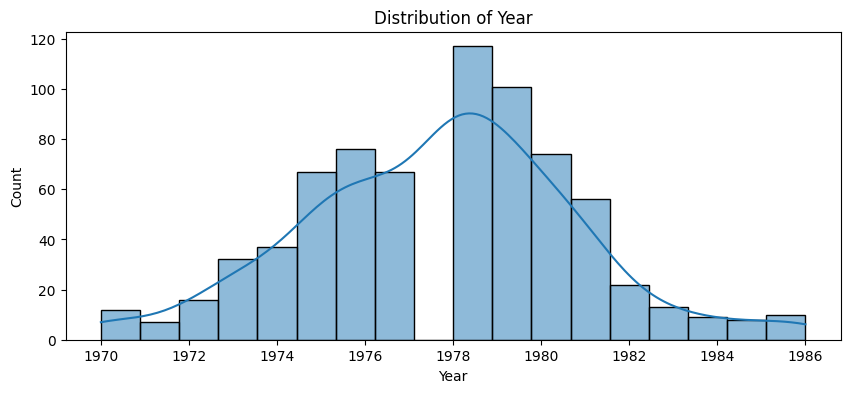

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


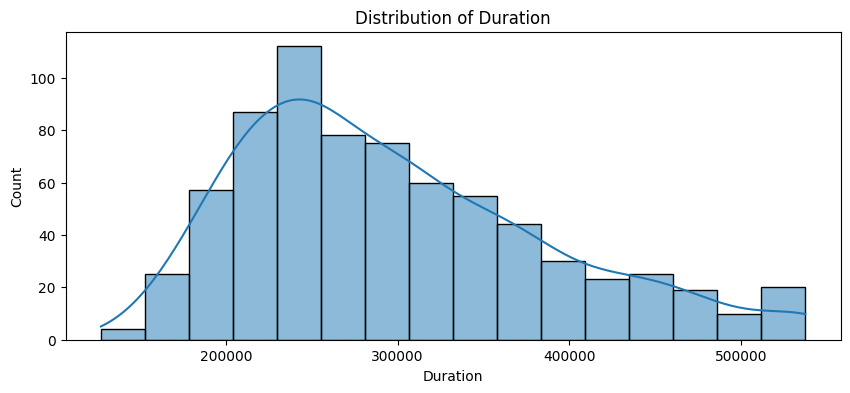

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


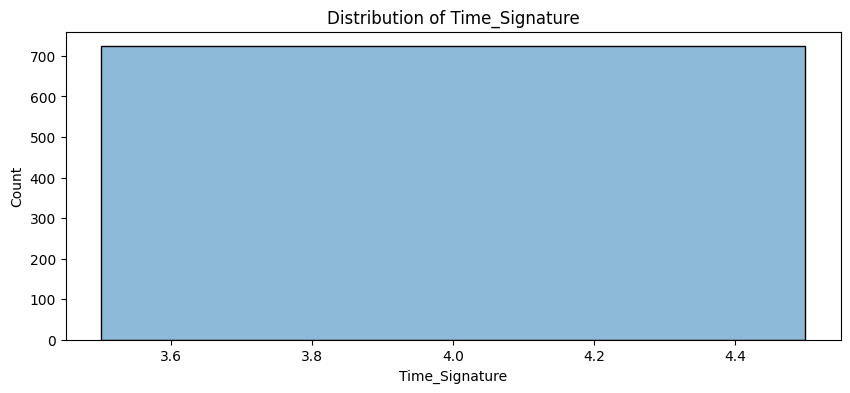

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


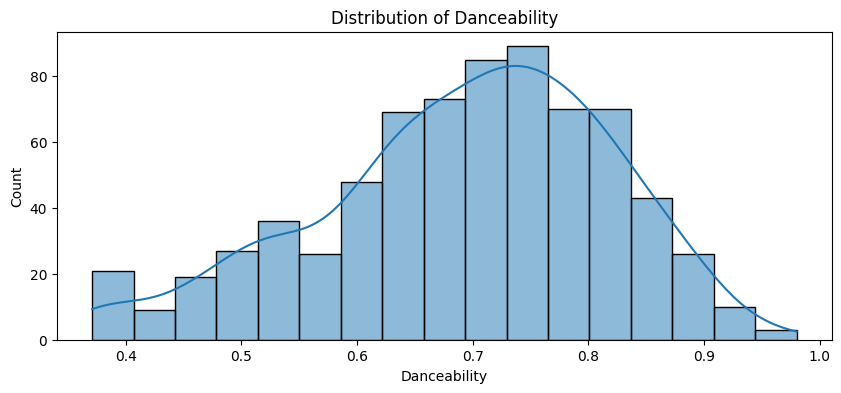

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


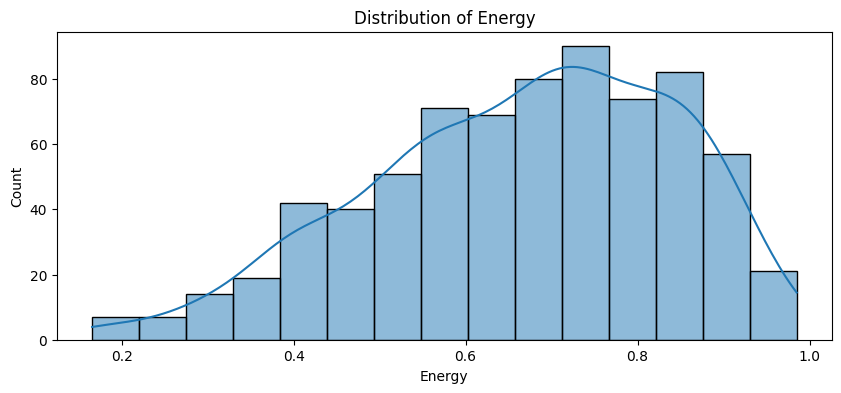

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


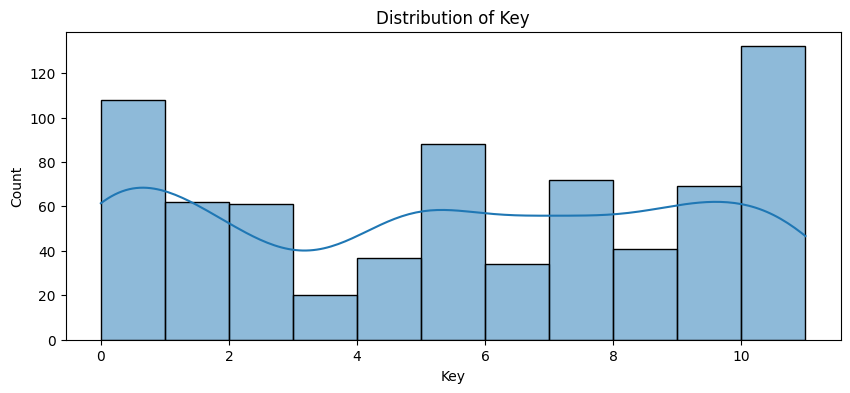

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


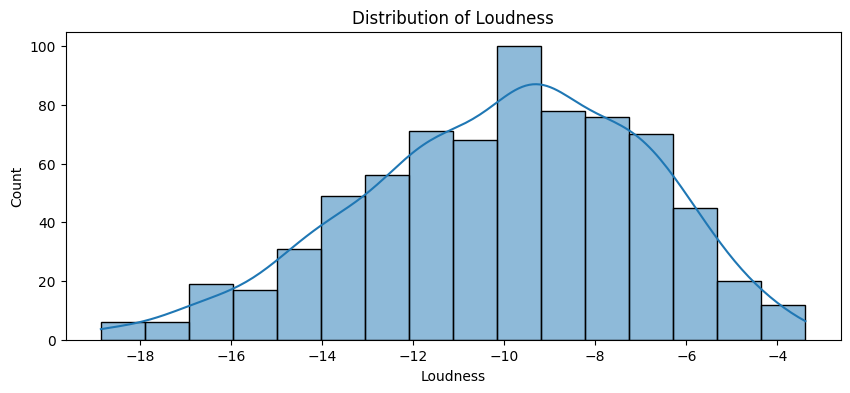

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


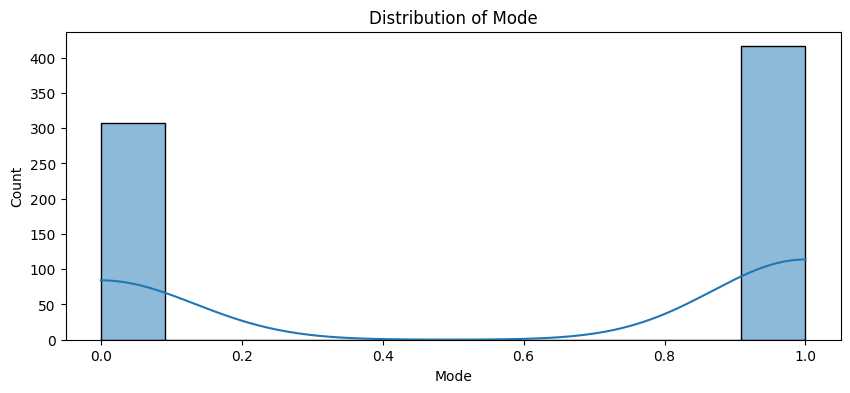

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


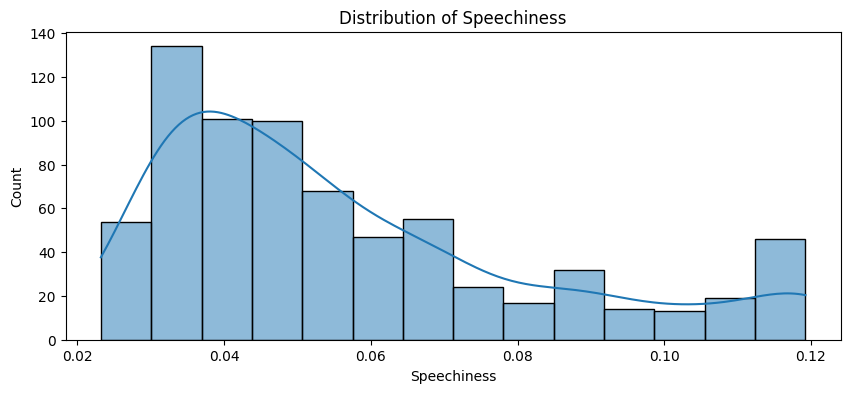

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


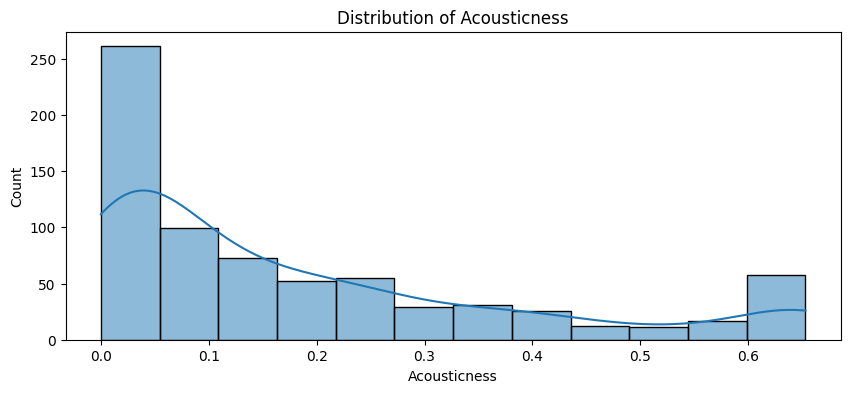

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


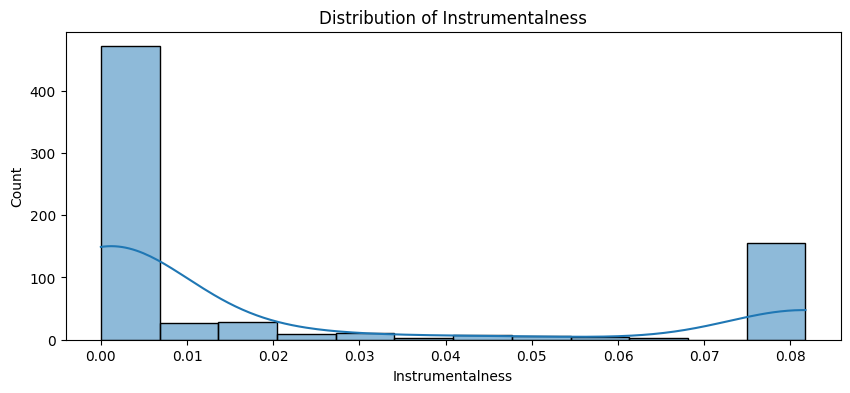

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


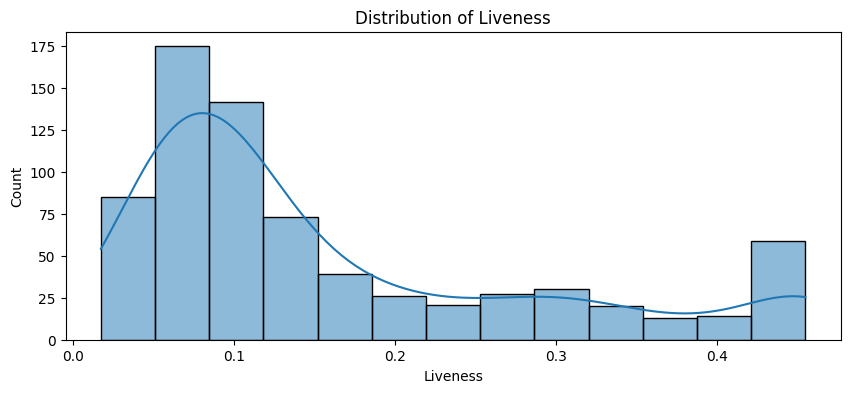

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


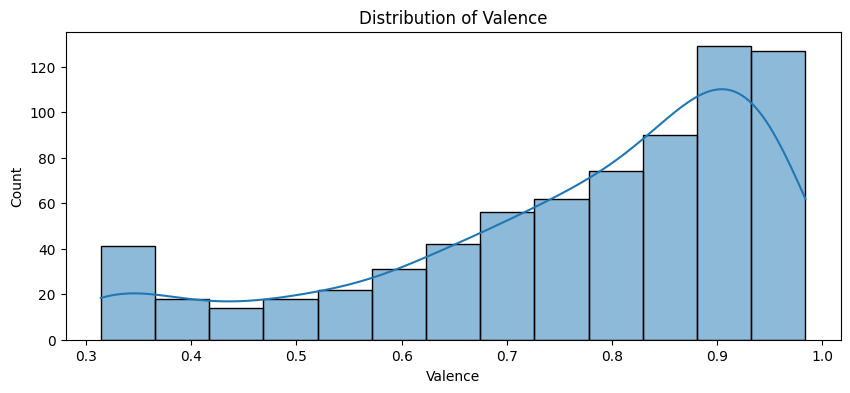

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


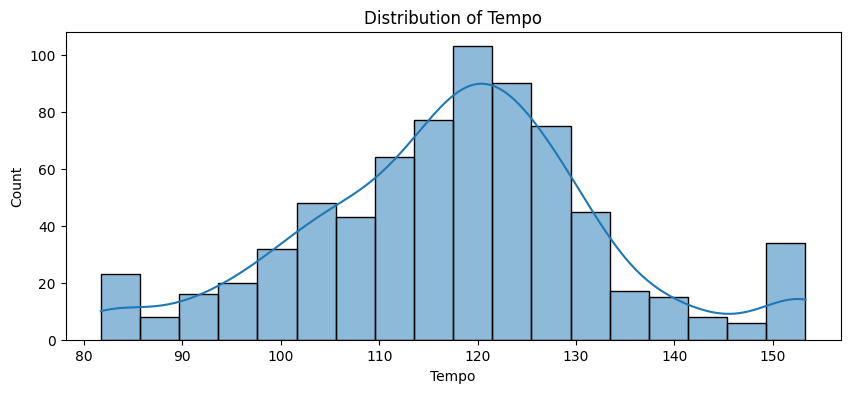

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


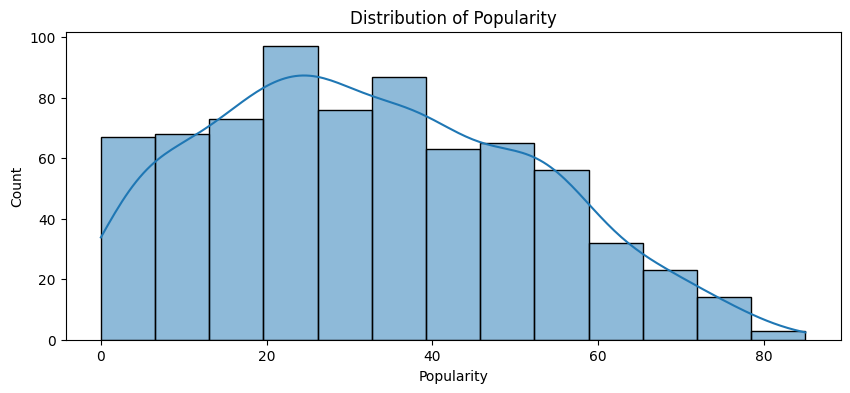

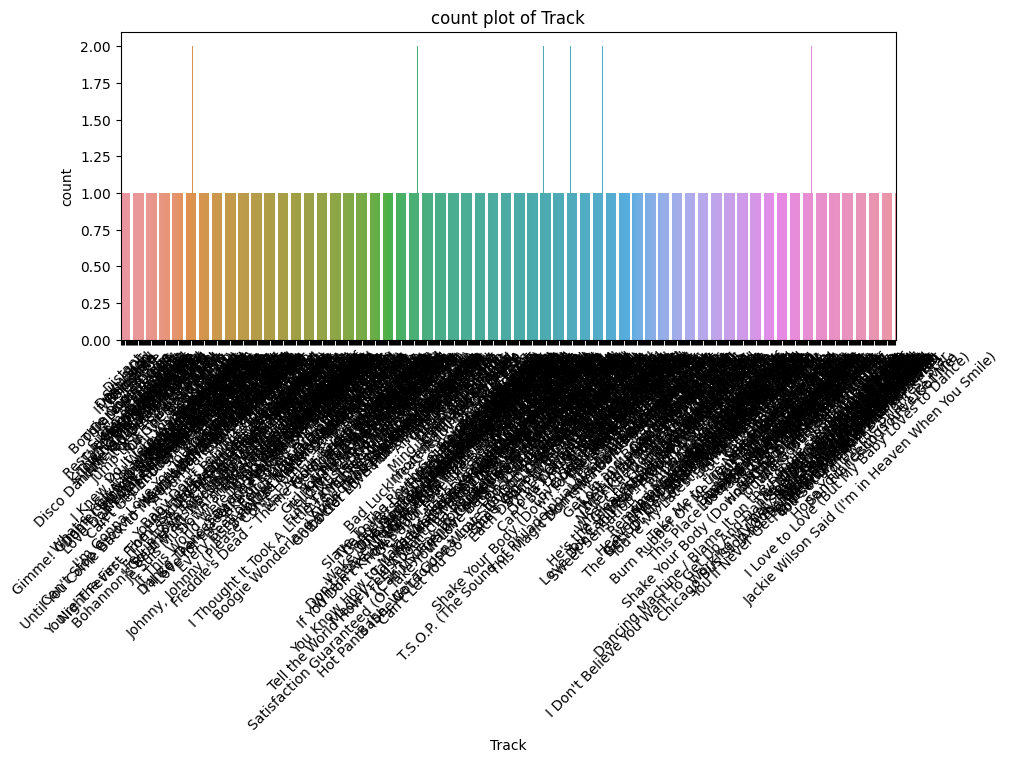

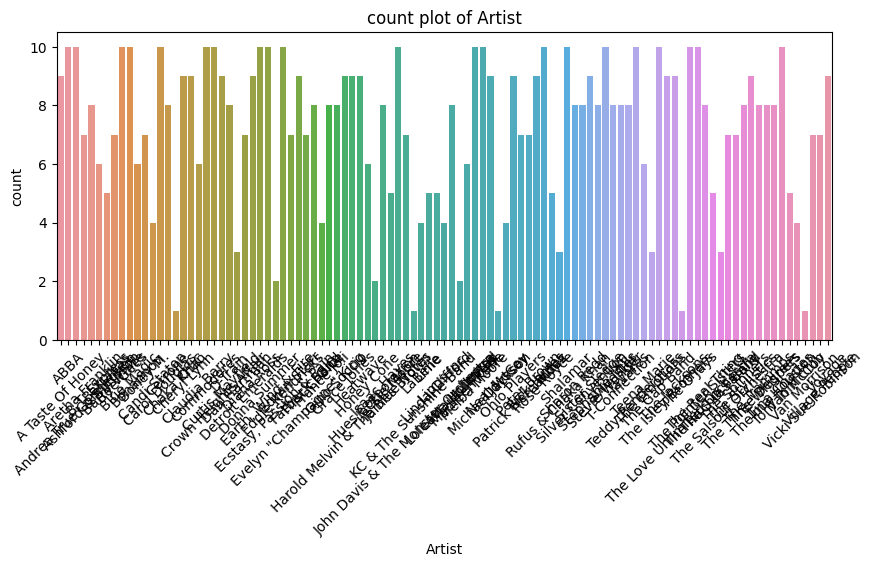

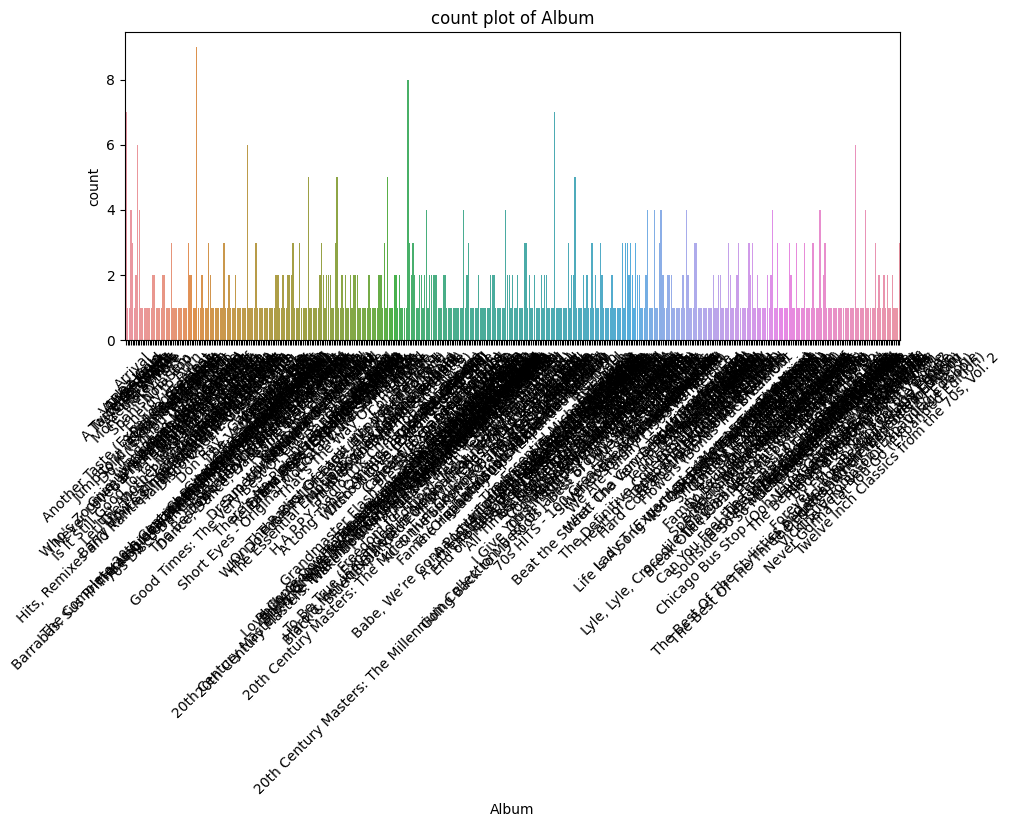

Correlation with Duration variables:
Instrumentalness    0.245060
Year                0.172858
Danceability        0.102356
Energy              0.070247
Speechiness         0.067322
Tempo               0.027473
Valence             0.014676
Key                 0.010596
Loudness           -0.062907
Mode               -0.088723
Liveness           -0.109292
Popularity         -0.117481
Acousticness       -0.237294
Time_Signature           NaN
Name: Duration, dtype: float64


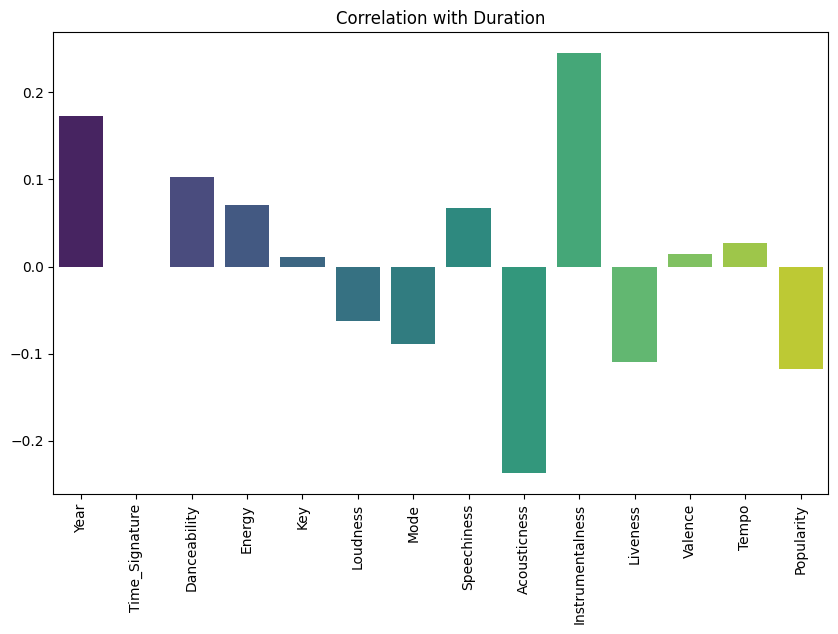

In [17]:
# 2 B)

numerical_vars = df.select_dtypes(include=['int64','float64'])
for col in numerical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.histplot(df[col],kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
    
categorical_vars = df.select_dtypes(include=['object','category'])
for col in categorical_vars.columns:
    plt.figure(figsize=(10,4))
    sns.countplot(x=df[col])
    plt.title(f'count plot of {col}')
    plt.xticks(rotation=45)
    plt.show()
    
Duration = 'Duration'
if Duration in df.columns:
    df_numerical = df.select_dtypes(include=['int64','float64'])
    correlations = df_numerical.corr()[Duration].drop(Duration)
    
    print("Correlation with Duration variables:")
    print(correlations.sort_values(ascending=False))
    plt.figure(figsize=(10,6))
    sns.barplot(x=correlations.index,y=correlations.values, palette='viridis')
    plt.title(f'Correlation with {Duration}')
    plt.xticks(rotation=90)
    plt.show()

In [19]:
# 2 C)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
variables_to_exclude = ['Track','Album']
df_cleaned = df.drop(columns=variables_to_exclude)

Duration = 'Duration'
if Duration in df_cleaned.columns:
    x = df_cleaned.drop(columns=[Duration])
    y = df_cleaned[Duration]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
    scaler = StandardScaler()
    numerical_features = x_train.select_dtypes(include=['int64','float64']).columns
    x_train[numerical_features] = scaler.fit_transform(x_train[numerical_features])
    x_test[numerical_features] = scaler.transform(x_test[numerical_features])
    
    print("Data preparation complete, the dataset is now reday for model creation.")

Data preparation complete, the dataset is now reday for model creation.


In [21]:
# 2 D)

from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

categorical_vars = df.select_dtypes(include=['object','category']).columns

label_encoders = {}
for col in categorical_vars:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col]= le
print("Label Encoding completed.")

df_encoded = pd.get_dummies(df,columns=categorical_vars,drop_first=True)
print("One-hot Encoding completes.")

preprocessor = ColumnTransformer(
transformers=[
    ('cat', OneHotEncoder(drop='first'), categorical_vars)
],
remainder='passthrough')

x = preprocessor.fit_transform(df)
print("Column Transformer completed.")

Label Encoding completed.
One-hot Encoding completes.
Column Transformer completed.


In [30]:
# 2 E)

from sklearn.model_selection import train_test_split
from scipy import stats

Duration = 'Duration'
if Duration in df.columns:
    x = df.drop(columns=[Duration])
    y=df[Duration]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3, random_state=42)
    def comapre_distribution(df1,df2,columns):
        for col in columns:
            if df1[col].dtype in ['int64','float64']:
                _,p_value = stats.ks_2samp(df1[col],df2[col])
                print(f"Kolmogorov-SMirnov test p-value for {col}: {p_value:.4f}")
                if p_value <0.05:
                    print(f"Distribution of {col} is significantly different between training and testing sets.")
                else:
                    print(F"Distribution of {col} is similar between training and testing sets.")
            else:
                contingency = pd.crosstab(df1[col],df2[col])
                _,p_value, _,_ = stats.chi2_contingency(contingency)
                print(f"Chi-square test p-value for {col}: {p_value:.4f}")
                if p_value <0.05:
                    print(f"Distribution of {col} is significantly different between training and testing sets.")
                    if p_value <0.05:
                        print(f"distribution of {col} is significantly dieefent between training and testing sets.")
                    else:
                        print(f"Distribution of {col} is similar between training and testing sets.")
        compare_distributions(pd.concat([x_train,y_train], axis=1), pd.concat([x_test,y_test], axis=1),x.columns)

In [37]:
# 3 A)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

Duration = 'Duration'
if Duration in df.columns:
    x=df.drop(columns=[Duration])
    y=df[Duration]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    mse=mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(f"Mean squared error of Linear regression model: {mse:.4f}")
    print(f"R^2 score of linear regression model: {r2:.4f}")
    
    
 # key Obseravtions:

# 1) Linear Regression: A fundamental regression technique that models the relationship between 
#     dependent and independent varaibels lineraly.

# 2) Baseline Performance: models serve as a baseline to evaluate more complex algorithims.they help 
#    establish a performance benchmark.
# 3)Interpretability: Coefficients represent the effect of each feature on the Duration variable,providing 
#   clear insight into relationship within the data.
#4) Computational Efficiency: models are computationally efficient and require less computational power 
#  compared to more complex models, making htem ideal for initial explorations.
#5) For Regression: Mean Squared Error(MSE) indicates the average squared diffrence between predicted 
#   and actual values.lower MSE signifies better model performance.
# 6) R^2 scores: Represents the proportion of variance explained by the model.A higher R^2 value 
#    indicates a better fit to the data.


Mean squared error of Linear regression model: 7895541408.2806
R^2 score of linear regression model: 0.0742


In [40]:
# 3 B)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

Duration = 'Duration'
if Duration in df.columns:
    x=df.drop(columns=[Duration])
    y=df[Duration]
    
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(x_train,y_train)
    
    y_pred = model.predict(x_test)
    
    mse = mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    
    print(f"Mean squared erroe of the linear regression model: {mse:.4f}")
    print(f"R^2 score of the Linear regression model: {r2:.4f}")
    
# Key Observations:
# 1) Accuracy: Represents the proportion of correct predictions out of the total predictions.generally,an
#  accuracy above 0.8(or 80%)is considered good for many applications,but it depends on the problem domain
#    and the distribution of classes.

# 2) Good or Not: an accuracy score is considered good if it meets or exceeds the baseline expectations.for
#   imbalanced
#  datasets, consider additional metrics like precision,recall,and f1-score to evaluate performance more 
#  comprehensively.

#3) For Regression: Mean Squared Erroe(MSE) Lower MSE indicates a better fit.MSE should be as low as
# possible,but its interpretation
# depends on the scale of the Duration variable.
    
# 4) R^2 Score: Ranges from 0 to 1, with higher values indicating better performances.An R^2 score 
# above 0.7 is generally
# considered good,though this can vary based on the complexity of the data.

# 5) Summary : Classification Accuracy a high accuarcy indicates that the model performs well on the 
# test data.however,be cautious of accuracy alone in cases of 
# class imbalances.

# 6) Regression Metrics (MSE and R^2) : Provide insight into how well the model predicts continuous 
# outcomes.Low MSE and high R^2
# indicate a well-performing model.



Mean squared erroe of the linear regression model: 7895541408.2806
R^2 score of the Linear regression model: 0.0742


In [59]:
# 3 C)
from sklearn.metrics import precision_score,recall_score,f1_score,classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import load_iris

data = load_iris()
x = data.data
y=data.target  # (you have to take same name target and data here dont change it please other wise you get wrong answer)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)

precision = precision_score(y_test,y_pred,average='weighted')
recall = recall_score(y_test,y_pred,average='weighted')
f1 = f1_score(y_test,y_pred,average='weighted')

print("precision:", precision)
print("Recall:", recall)
print("f1 score:",f1)

print("\nClassification Report :")
print(classification_report(y_test,y_pred))

# key observations
# 1) precision : is the ratio of correctly predicted positive observation to the total predicted positives.
# it is useful when the cpst of false positive is high
#2) Recall: (also known as sensitivity) is the ratio of correctly predicted positive observation to all 
# observation in the actual class. it is important when the cost of false negative is high.

# 3) F1 score : Is the harmonic mean of precision and recall it is a good metric when you need a balance 
# between precision and recall and there is an uneven class distribution.

# 4) Choosing the right metric depends on the problem statement: if false positive are costly
#(eg.,email spma detection)prioritize precision.
# if false negative are costly(eg., medical daignoses),prioritize recall.
# if you need a balance or if the classes are imabalanced, use F1 score.


        
        
        
        
        
        
    

precision: 1.0
Recall: 1.0
f1 score: 1.0

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [9]:
# 3 D)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

data = load_iris()
x = data.data
y=data.target # (you have to take same name target and data here dont change it please other wise you get wrong answer)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('model',RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [50,100,200],
    'model__max_depth': [None,10,20,30]
    }

grid_search = GridSearchCV(pipeline,param_grid,cv=5,scoring='accuracy')
grid_search.fit(x_train,y_train)

best_model = grid_search.best_estimator_

y_pred = best_model.predict(x_test)

accuracy = accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test,y_pred))

print("\nBest parameters:",grid_search.best_params_)


# Key Observations
# 1) Data preprocessing: added feature scaling using standardscaler
# 2) Model selection : Used a pipeline to combine scaling and model training.
#   implemented GridsearchCV to find optimal hyperparameters for RandomForestClassifier.
# 3) Cross validation : Include cross-validation in gridSearchCV to ensure the model generalize well.
#4) By following these steps, you should see an improvement in the accuracy of your model.Adjustments to
# hyperparameters,preprocessing,and model choice should be based on the specific characteristics of your 
# dataset and problem.

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45


Best parameters: {'model__max_depth': None, 'model__n_estimators': 50}


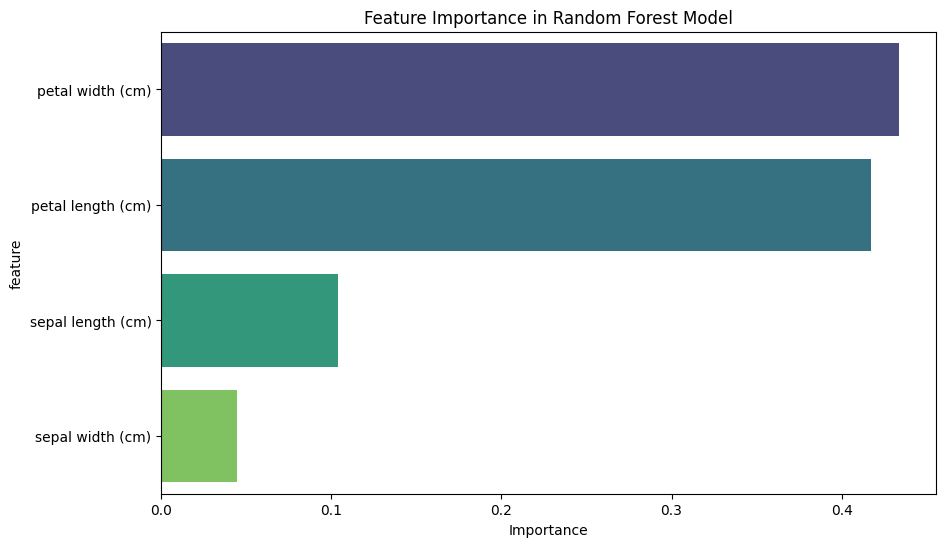

In [12]:
# 3 E)

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data =load_iris()
x = pd.DataFrame(data.data,columns=data.feature_names)
y = data.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.3,random_state=42)

model = RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)

feature_importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': x.columns,
    'Importance': feature_importances
    
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance',y='feature',data=feature_importance_df,palette='viridis')
plt.title('Feature Importance in Random Forest Model')
plt.xlabel('Importance')
plt.ylabel('feature')
plt.show()

# Key observations.
# Business Interpretation of the model
# 1) Top Featutes Affecting the Target : The bar chart displays the most important fetaures 
#influencing the target variables.
# in this example using the iris dataset,fetaures like "petal length (cm)"and "petal width (cm)" 
#have the highest importance,
# indicating they are the most influential in predicting the target variable (species of the flower).

# 2)Understanding Feature Relationships: The relationship between the feature and the target can be 
#further understood
# using additional,plots such as partial dependence plots or shap values,for example,if"petal length"
#has the highest
#importance,we might examine how changes in petal length impact the predicted probability of 
#different flower species.

